<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week1_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [3]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]

#Add Polinomial Terms
X["Radius_Mean_Sq"] = X["radius1"] **2
X["Radius_Worst_Sq"] = X["radius3"] **2
X["Concave_Points_Worst_Sq"] = X["concave_points3"] **2

#Add Interaction Terms
X["Radius_Texture"] = (X["radius1"] * X["texture1"])
X["Area_Perimeter"] = (X["area1"] * X["perimeter1"])
X["Radius_ConcavePt"] = (X["radius3"] * X["concave_points3"])
X["compactness_concavity"] = (X["compactness3"] * X["concavity3"])

#Check Multicollinearity
X_vif = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factors:")
print(vif_data.sort_values(by="VIF", ascending=False))

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

#Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

#Evaluation
mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
print("MSE: ", mse)
print("R2 score: ", r2)

#Coefficients
coef_df = pd.DataFrame({"Feature": X.columns,
                        "Coefficient": model.coef_})
print("Regression Coefficients:")
print(coef_df.sort_values(by="Coefficient", ascending=False))

#Statsmodel Summary
X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()

print("OLS Regression Summary")
print(ols_model.summary())



Variance Inflation Factors:
                    Feature          VIF
1                   radius1  9696.336984
31           Radius_Mean_Sq  7036.806378
3                perimeter1  6923.443227
0                     const  5125.390144
4                     area1  4706.184108
32          Radius_Worst_Sq  1496.556413
35           Area_Perimeter  1368.540207
24                    area3  1010.382358
21                  radius3  1003.748371
36         Radius_ConcavePt   430.253831
23               perimeter3   411.186718
28          concave_points3   129.972213
33  Concave_Points_Worst_Sq    94.583341
11                  radius2    79.580972
7                concavity1    79.304535
34           Radius_Texture    75.944093
6              compactness1    74.777101
13               perimeter2    74.374698
14                    area2    72.722475
8           concave_points1    65.157607
26             compactness3    50.701236
27               concavity3    48.986575
2                  texture1  

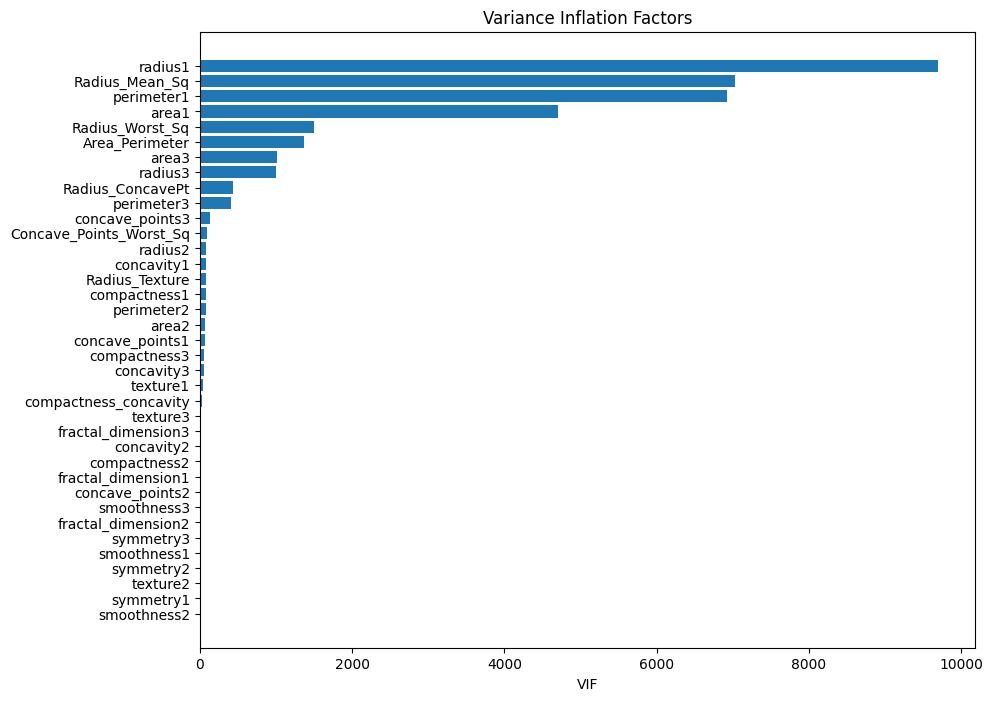

In [7]:
#Visualize multicollinearity
import matplotlib.pyplot as plt
vif_plot = vif_data[vif_data["Feature"] != "const"]
vif_plot = vif_plot.sort_values("VIF", ascending=True)

plt.figure(figsize=(10,8))
plt.barh(vif_plot["Feature"], vif_plot["VIF"])
plt.xlabel("VIF")
plt.title("Variance Inflation Factors")
plt.show()

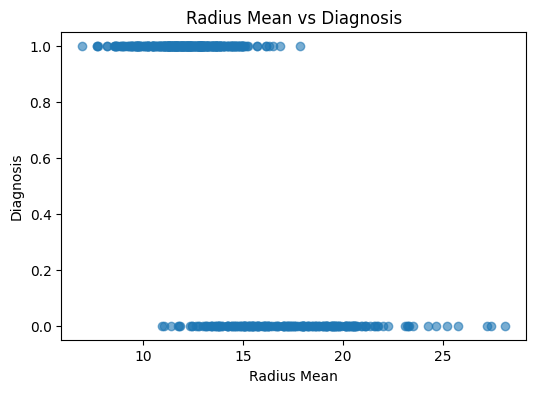

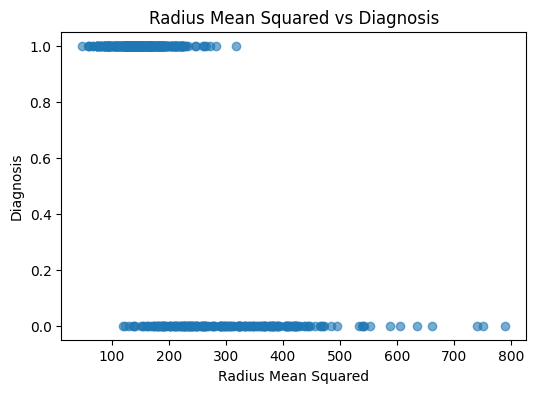

In [9]:
#Polynomial Feature Relationship
plt.figure(figsize=(6,4))
plt.scatter(X["radius1"], y, alpha=0.6)
plt.xlabel("Radius Mean")
plt.ylabel("Diagnosis")
plt.title("Radius Mean vs Diagnosis")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X["Radius_Mean_Sq"], y, alpha=0.6)
plt.xlabel("Radius Mean Squared")
plt.ylabel("Diagnosis")
plt.title("Radius Mean Squared vs Diagnosis")
plt.show()

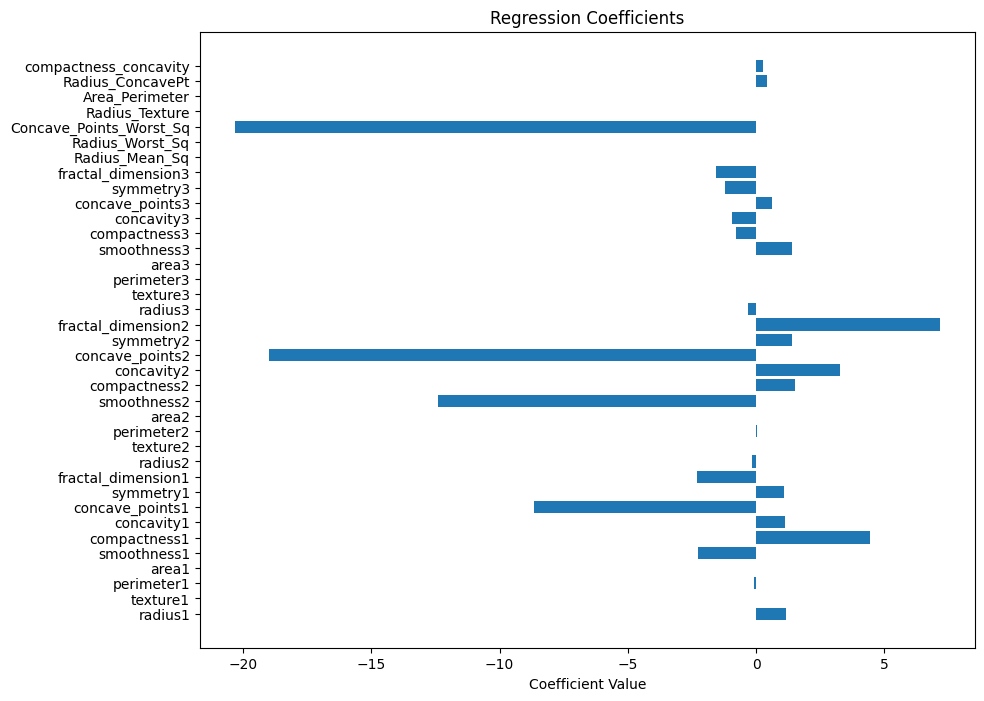

In [10]:

#Coefficient Importance
plt.figure(figsize=(10,8))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Regression Coefficients")
plt.show()